In [30]:
import pandas as pd
from rich import print as rprint 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [22]:
import os

rating_file_path = '../../data/mv-lens-32m/ml-32m/ratings.csv'
movies_file_path = '../../data/mv-lens-32m/ml-32m/movies.csv'


if os.path.exists(rating_file_path) and os.path.exists(movies_file_path):
    ratings_df = pd.read_csv(rating_file_path)
    movies_df = pd.read_csv(movies_file_path)
else:
    rprint('file not found!')
    # Execute the download script
    import subprocess
    subprocess.run(['../../start.sh'])
    ratings_df = pd.read_csv(rating_file_path)
    movies_df = pd.read_csv(movies_file_path)
rprint(ratings_df)
rprint(movies_df)



userId  movieId  rating   timestamp
0              1       17     4.0   944249077
1              1       25     1.0   944250228
2              1       29     2.0   943230976
3              1       30     5.0   944249077
4              1       32     5.0   943228858
...          ...      ...     ...         ...
32000199  200948    79702     4.5  1294412589
32000200  200948    79796     1.0  1287216292
32000201  200948    80350     0.5  1294412671
32000202  200948    80463     3.5  1350423800
32000203  200948    87304     4.5  1350423523

[32000204 rows x 4 columns]

movieId                               title  \
0            1                    Toy Story (1995)   
1            2                      Jumanji (1995)   
2            3             Grumpier Old Men (1995)   
3            4            Waiting to Exhale (1995)   
4            5  Father of the Bride Part II (1995)   
...        ...                                 ...   
87580   292731           The Monroy Affaire (2022)   
87581   292737          Shelter in Solitude (2023)   
87582   292753                         Orca (2023)   
87583   292755              The Angry Breed (1968)   
87584   292757           Race to the Summit (2023)   

                                            genres  
0      Adventure|Animation|Children|Comedy|Fantasy  
1                       Adventure|Children|Fantasy  
2                                   Comedy|Romance  
3                             Comedy|Drama|Romance  
4                                           Comedy  
...                                            ...  
87580                                        Drama  
87581                                 Comedy|Drama  
87582                                        Drama  
87583                                        Drama  
87584                 Action|Adventure|Documentary  

[87585 rows x 3 columns]

In [23]:
merged_df = pd.merge(ratings_df, movies_df, on='movieId', how='left')
rprint(merged_df.head())


userId  movieId  rating  timestamp  \
0       1       17     4.0  944249077   
1       1       25     1.0  944250228   
2       1       29     2.0  943230976   
3       1       30     5.0  944249077   
4       1       32     5.0  943228858   

                                               title  \
0                       Sense and Sensibility (1995)   
1                           Leaving Las Vegas (1995)   
2  City of Lost Children, The (Cité des enfants p...   
3  Shanghai Triad (Yao a yao yao dao waipo qiao) ...   
4          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   

                                   genres  
0                           Drama|Romance  
1                           Drama|Romance  
2  Adventure|Drama|Fantasy|Mystery|Sci-Fi  
3                             Crime|Drama  
4                 Mystery|Sci-Fi|Thriller

In [24]:
merged_df.shape

(32000204, 6)

In [26]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
 4   title      object 
 5   genres     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 1.4+ GB


In [27]:
merged_df.describe()

,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09


In [71]:
# Check for missing values
missing_values = merged_df.isnull().sum()
rprint(missing_values)



userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [72]:
merged_df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')

Ratings column summary:

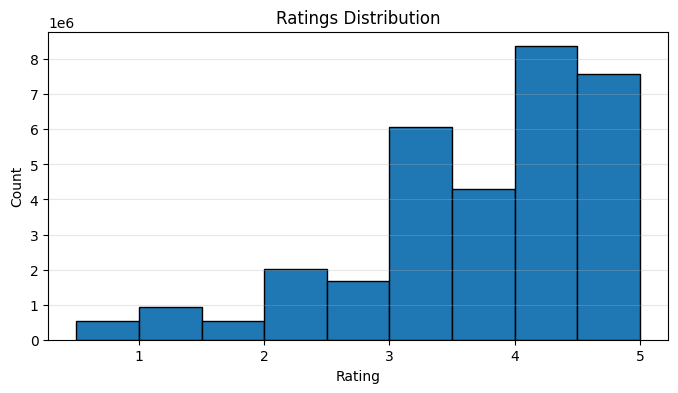

Count of ratings per rating score:

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

In [37]:
# Basic inspection of rating column
rprint("[bold cyan]Ratings column summary:[/bold cyan]")

# Histogram of rating values (0.5 to 5.0, usually in 0.5 steps)
fig , ax = plt.subplots(figsize=(8, 4) )
ax.hist(merged_df['rating'], bins=[x / 2 for x in range(1, 11)], edgecolor='black')
ax.set_title('Ratings Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
# ax.tight_layout()
plt.show()

# Count of ratings per rating score
rating_counts = merged_df['rating'].value_counts().sort_index()
rprint("[bold cyan]Count of ratings per rating score:[/bold cyan]")
rprint(rating_counts)

Number of ratings per user (first 10 users):

userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
10202      7748
198515     7594
49305      7488
22744      7372
7858       7322
Name: rating, dtype: int64

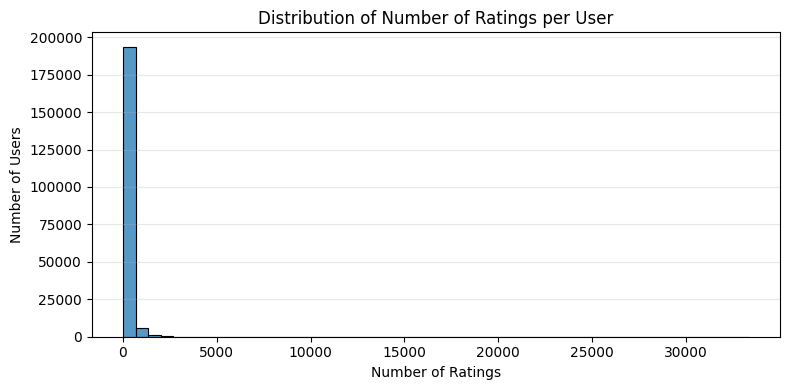

Power users (top 1% by rating count, threshold = 1290 ratings):

userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
10202      7748
198515     7594
49305      7488
22744      7372
7858       7322
14674      6407
53192      6265
133878     6074
57304      6061
129705     5812
139018     5806
43703      5784
68797      5693
103925     5655
119247     5654
Name: rating, dtype: int64

Total number of power users: 2014

Inactive users (<= 5 ratings):

Series([], Name: rating, dtype: int64)

Total number of inactive users: 0

In [41]:
# User Activity Analysis

# Number of ratings per user
user_rating_counts = merged_df.groupby('userId')['rating'].count().sort_values(ascending=False)

rprint("[bold magenta]Number of ratings per user (first 10 users):[/bold magenta]")
rprint(user_rating_counts.head(10))


plt.figure(figsize=(8, 4))
sns.histplot(user_rating_counts, bins=50, kde=False)
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Identify power users (top X% or above a threshold)
# Here: users in the top 1% by number of ratings
threshold_power = user_rating_counts.quantile(0.99)
power_users = user_rating_counts[user_rating_counts >= threshold_power]

rprint(f"[bold magenta]Power users (top 1% by rating count, threshold = {threshold_power:.0f} ratings):[/bold magenta]")
rprint(power_users.head(20))  # show first 20
rprint(f"Total number of power users: {len(power_users)}")

# Identify inactive users
# Here: users with very few ratings (e.g., <= 5 ratings)
inactive_threshold = 5
inactive_users = user_rating_counts[user_rating_counts <= inactive_threshold]

rprint(f"[bold magenta]Inactive users (<= {inactive_threshold} ratings):[/bold magenta]")
rprint(inactive_users.head(20))  # show first 20
rprint(f"Total number of inactive users: {len(inactive_users)}")

Most-rated movies (top 20):

movieId  title                                                                         
318      Shawshank Redemption, The (1994)                                                  102929
356      Forrest Gump (1994)                                                               100296
296      Pulp Fiction (1994)                                                                98409
2571     Matrix, The (1999)                                                                 93808
593      Silence of the Lambs, The (1991)                                                   90330
260      Star Wars: Episode IV - A New Hope (1977)                                          85010
2959     Fight Club (1999)                                                                  77332
480      Jurassic Park (1993)                                                               75233
527      Schindler's List (1993)                                                            73849
4993     Lord of the Rings: The Fellowship of the Ring, The (2001)                          73122
1196     Star Wars: Episode V - The Empire Strikes Back (1980)                              72151
110      Braveheart (1995)                                                                  69482
1        Toy Story (1995)                                                                   68997
589      Terminator 2: Judgment Day (1991)                                                  68383
50       Usual Suspects, The (1995)                                                         67750
1210     Star Wars: Episode VI - Return of the Jedi (1983)                                  67496
5952     Lord of the Rings: The Two Towers, The (2002)                                      67463
7153     Lord of the Rings: The Return of the King, The (2003)                              67449
1198     Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)     67408
858      Godfather, The (1972)                                                              66440
Name: rating, dtype: int64

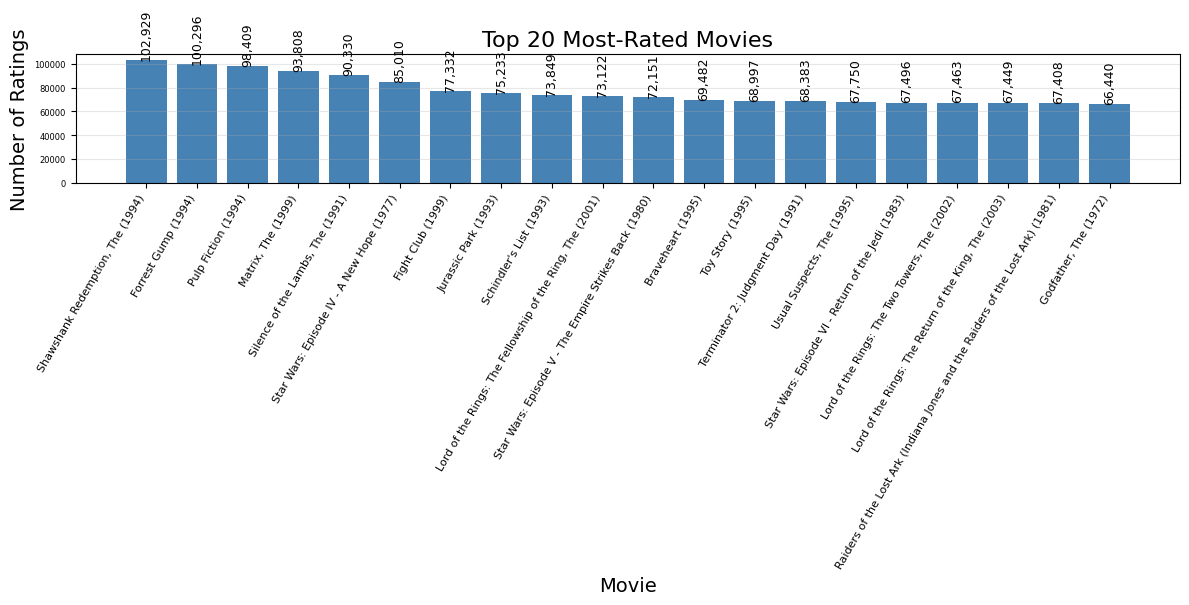

In [67]:
# Movie Popularity Analysis

# Number of ratings per movie
movie_rating_counts = merged_df.groupby(['movieId', 'title'])['rating'].count().sort_values(ascending=False)

rprint("[bold green]Most-rated movies (top 20):[/bold green]")
most_rated_movies = movie_rating_counts.head(20)
rprint(most_rated_movies)

# Prepare data for plotting: extract titles and counts
top20_df = most_rated_movies.reset_index(name='rating_count')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top20_df['title'], top20_df['rating_count'], color='steelblue')
ax.set_title('Top 20 Most-Rated Movies', fontsize=16)
ax.set_xlabel('Movie', fontsize=14)
ax.set_ylabel('Number of Ratings', fontsize=14)
ax.tick_params(axis='y', labelsize=6)
ax.set_xticks(range(len(top20_df['title'])))
ax.set_xticklabels(top20_df['title'], rotation=60, ha='right', fontsize=8)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9, rotation=90)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Movie stats (first 10 rows):

movieId                               title  avg_rating  rating_count
0        1                    Toy Story (1995)    3.897438         68997
1        2                      Jumanji (1995)    3.275758         28904
2        3             Grumpier Old Men (1995)    3.139447         13134
3        4            Waiting to Exhale (1995)    2.845331          2806
4        5  Father of the Bride Part II (1995)    3.059602         13154
5        6                         Heat (1995)    3.868277         29490
6        7                      Sabrina (1995)    3.363968         13585
7        8                 Tom and Huck (1995)    3.115563          1510
8        9                 Sudden Death (1995)    2.987723          4154
9       10                    GoldenEye (1995)    3.427850         32474

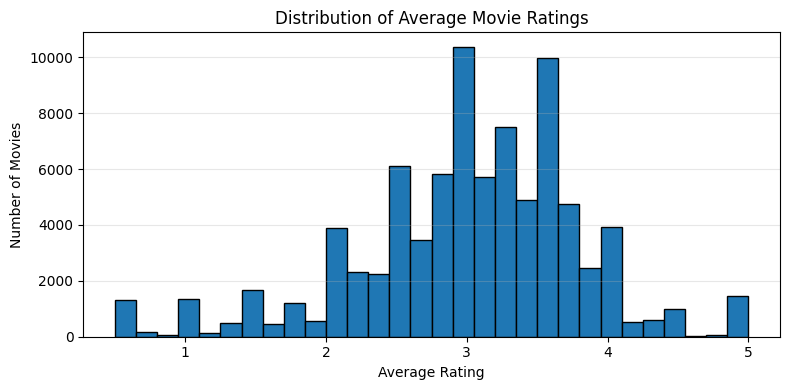

Number of movies with at least 20 ratings: 23350

Top 20 highest-rated movies (>= 20 ratings):

movieId                                              title  avg_rating  \
44190   171011                             Planet Earth II (2016)    4.446830   
39306   159817                                Planet Earth (2006)    4.444369   
44042   170705                            Band of Brothers (2001)    4.426539   
314        318                   Shawshank Redemption, The (1994)    4.404614   
44337   171331       The Work of Director Chris Cunningham (2003)    4.395833   
44416   171495                                             Cosmos    4.330081   
840        858                              Godfather, The (1972)    4.317030   
58698   202439                                    Parasite (2019)    4.312254   
34288   147124         The Roosevelts: An Intimate History (2014)    4.306818   
47975   179135                              Blue Planet II (2017)    4.300086   
56760   198185                                  Twin Peaks (1989)    4.298684   
65936   220528                            Twelve Angry Men (1954)    4.286192   
71289   242210  James Acaster: Cold Lasagne Hate Myself 1999 (...    4.272727   
1173      1203                                12 Angry Men (1957)    4.265311   
49          50                         Usual Suspects, The (1995)    4.265070   
1190      1221                     Godfather: Part II, The (1974)    4.264468   
40994   163809                        Over the Garden Wall (2013)    4.263780   
49605   182723                        Cosmos: A Spacetime Odissey    4.250842   
1930      2019        Seven Samurai (Shichinin no samurai) (1954)    4.249622   
32219   142115                             The Blue Planet (2001)    4.247408   

       rating_count  
44190          1956  
39306          2948  
44042          2811  
314          102929  
44337            24  
44416           615  
840           66440  
58698         11670  
34288            44  
47975          1163  
56760          1140  
65936           449  
71289            22  
1173          21863  
49            67750  
1190          43111  
40994          1397  
49605           594  
1930          16531  
32219          1061

Top 20 lowest-rated movies (>= 20 ratings):

movieId                                              title  avg_rating  \
60326   206190                       6-Headed Shark Attack (2018)    0.860000   
8146      8859                SuperBabies: Baby Geniuses 2 (2004)    0.865759   
7158      7282                           Hip Hop Witch, Da (2000)    0.866667   
32165   141994                            Saving Christmas (2014)    0.871429   
20790   107704                     Justin Bieber's Believe (2013)    0.909091   
48262   179747                                      Crimea (2017)    0.937500   
23792   120222                                  Foodfight! (2012)    0.989130   
6361      6483                        From Justin to Kelly (2003)    1.006356   
4670      4775                                     Glitter (2001)    1.128798   
12034    56835                                Pledge This! (2006)    1.166667   
33484   145096  Barbie & Her Sisters in the Great Puppy Advent...    1.180556   
1740      1826                    Barney's Great Adventure (1998)    1.197727   
6465      6587                                       Gigli (2003)    1.204057   
9607     31698                             Son of the Mask (2005)    1.220553   
24057   121103              Justin Bieber: Never Say Never (2011)    1.238095   
12618    61348                              Disaster Movie (2008)    1.248252   
36065   151913                            The Best Movie 2 (2009)    1.250000   
27334   130398                               Transmorphers (2007)    1.261905   
5628      5739                            Faces of Death 6 (1996)    1.284884   
36424   152755                                Atlantic Rim (2013)    1.300000   

       rating_count  
60326            25  
8146            257  
7158             30  
32165            35  
20790            22  
48262            24  
23792            46  
6361            472  
4670            757  
12034            30  
33484            72  
1740            440  
6465            838  
9607            832  
24057            63  
12618           715  
36065            32  
27334            21  
5628            172  
36424            25

In [ ]:
# Movie Average Rating Analysis

# Compute mean rating and rating count per movie
movie_stats = merged_df.groupby(['movieId', 'title'])['rating'].agg(['mean', 'count']).reset_index()
movie_stats.rename(columns={'mean': 'avg_rating', 'count': 'rating_count'}, inplace=True)

rprint("[bold cyan]Movie stats (first 10 rows):[/bold cyan]")
rprint(movie_stats.head(10))    

# Distribution of average ratings
plt.figure(figsize=(8, 4))
plt.hist(movie_stats['avg_rating'], bins=30, edgecolor='black')
plt.title('Distribution of Average Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Identify highest-rated movies with a minimum rating-count threshold
min_ratings_threshold = 20
filtered = movie_stats[movie_stats['rating_count'] >= min_ratings_threshold]

rprint(f"[bold cyan]Number of movies with at least {min_ratings_threshold} ratings:[/bold cyan] {len(filtered)}")

# Sort by average rating descending, then by rating_count descending for tie-breaking
highest_rated = filtered.sort_values(by=['avg_rating', 'rating_count'], ascending=[False, False]).head(20)

rprint(f"[bold cyan]Top 20 highest-rated movies (>= {min_ratings_threshold} ratings):[/bold cyan]")
rprint(highest_rated[['movieId', 'title', 'avg_rating', 'rating_count']])

# Identify lowest-rated movies with the same threshold
lowest_rated = filtered.sort_values(by=['avg_rating', 'rating_count'], ascending=[True, False]).head(20)

rprint(f"[bold cyan]Top 20 lowest-rated movies (>= {min_ratings_threshold} ratings):[/bold cyan]")
rprint(lowest_rated[['movieId', 'title', 'avg_rating', 'rating_count']])


In [84]:

# Count number of ratings for each movieId, preserving title using .agg and merging back
movie_counts = merged_df.groupby(['movieId', 'title'])['rating'].count().reset_index(name='rating_count')

# Least-rated movies (e.g., movies with only 1 rating)
min_count = movie_counts['rating_count'].min()
least_rated_movies = movie_counts[movie_counts['rating_count'] == min_count]

# Optionally to display as before:
rprint("[bold green]Least-rated movies (movies with the minimum number of ratings):[/bold green]")
rprint(least_rated_movies.head(20))
rprint(f"Total number of movies with the minimum rating count ({min_count} ratings): {len(least_rated_movies)}")

Least-rated movies (movies with the minimum number of ratings):

movieId                                   title  rating_count
3263      3356                   Condo Painting (2000)             1
3463      3561                  Stacy's Knights (1982)             1
5794      5905                        Soap Girl (2002)             1
8373     25817                  Break of Hearts (1935)             1
8464     25935                  B.F.'s Daughter (1948)             1
8986     26769              Crossing the Bridge (1992)             1
9008     26815                     Deadly Advice(1994)             1
9034     26880                        Staggered (1994)             1
9619     31797                    White Banners (1938)             1
9644     31945              Always a Bridesmaid (2000)             1
10213    36543                 Crazy Like a Fox (2004)             1
11310    50279               My Bollywood Bride (2006)             1
11772    54614                 American Pastime (2007)             1
11998    56513                  Suicide Killers (2006)             1
12039    56874               Chicks with Sticks (2004)             1
12642    61569                      Jammed, The (2007)             1
12661    61868                              Jam (2006)             1
12763    63141           Rockin' in the Rockies (1945)             1
12917    65078         Jane Austen in Manhattan (1980)             1
12941    65277  Good Guys and the Bad Guys, The (1969)             1

Total number of movies with the minimum rating count (1 ratings): 18607